# Geometric Brownian Motion Simulation

This notebook simulates asset-price paths under geometric Brownian motion (GBM).

The model is

\[
dS_t = \mu S_t\,dt + \sigma S_t\,dW_t,
\]

with exact solution

\[
S_t = S_0 \exp\left(
\left(\mu-\frac{1}{2}\sigma^2\right)t+\sigma W_t
\right).
\]

Here:

- \(S_0\) is the initial asset price;
- \(\mu\) is the drift;
- \(\sigma\) is the volatility;
- \(W_t\) is a standard Brownian motion.



In [1]:
import numpy as np
import matplotlib.pyplot as plt


def simulate_gbm_paths(S0, mu, sigma, T, steps, paths, seed=None):
    """Simulate geometric Brownian motion price paths."""

    rng = np.random.default_rng(seed)
    dt = T / steps

    increments = rng.normal(
        loc=0.0,
        scale=np.sqrt(dt),
        size=(paths, steps)
    )

    brownian_paths = np.column_stack((
        np.zeros(paths),
        np.cumsum(increments, axis=1)
    ))

    time = np.linspace(0, T, steps + 1)

    prices = S0 * np.exp(
        (mu - 0.5 * sigma**2) * time
        + sigma * brownian_paths
    )

    return time, prices

In [2]:
S0 = 100
mu = 0.05
sigma = 0.20
T = 1
steps = 252
paths = 10

time, prices = simulate_gbm_paths(
    S0=S0,
    mu=mu,
    sigma=sigma,
    T=T,
    steps=steps,
    paths=paths,
    seed=42
)

print("Time shape:", time.shape)
print("Price shape:", prices.shape)
print("Initial prices:", prices[:, 0])

Time shape: (253,)
Price shape: (10, 253)
Initial prices: [100. 100. 100. 100. 100. 100. 100. 100. 100. 100.]


## Simulated price paths

The following figure shows ten simulated GBM price paths over one year,
using 252 time steps.

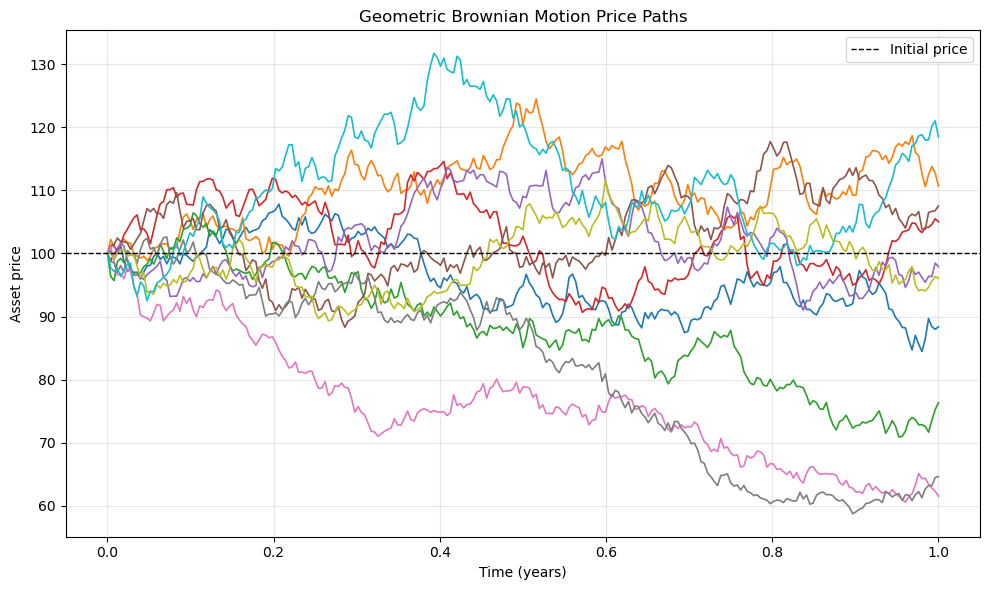

In [3]:
plt.figure(figsize=(10, 6))

for path in prices:
    plt.plot(time, path, linewidth=1.2)

plt.axhline(
    S0,
    color="black",
    linestyle="--",
    linewidth=1,
    label="Initial price"
)

plt.xlabel("Time (years)")
plt.ylabel("Asset price")
plt.title("Geometric Brownian Motion Price Paths")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Validation of the terminal mean

For geometric Brownian motion,

\[
\mathbb{E}[S_T] = S_0 e^{\mu T}.
\]

We compare this theoretical value with the mean terminal price obtained
from the simulation.

In [4]:
_, validation_prices = simulate_gbm_paths(
    S0=S0,
    mu=mu,
    sigma=sigma,
    T=T,
    steps=steps,
    paths=10_000,
    seed=123
)

simulated_mean = np.mean(validation_prices[:, -1])
theoretical_mean = S0 * np.exp(mu * T)
relative_error = abs(simulated_mean - theoretical_mean) / theoretical_mean

print(f"Simulated mean:   {simulated_mean:.4f}")
print(f"Theoretical mean: {theoretical_mean:.4f}")
print(f"Relative error:   {relative_error:.4%}")

Simulated mean:   105.5124
Theoretical mean: 105.1271
Relative error:   0.3665%


## Conclusion

The vectorised simulation generated multiple GBM price paths efficiently.
For 10,000 simulated paths, the mean terminal price was close to the
theoretical value \(S_0e^{\mu T}\), with a relative error below 0.4%.

This provides a numerical validation of the GBM implementation and the
Itô correction term in the exact solution.